In [ ]:
#!pip install torch pot gensim transformers

In [ ]:
#embeddings
#first part: downloading and using word embeddings previously trained from NILC
#NILC is a repository of word embeddings generaed for the Portuguese language
#more details can be found in the NILC website!

!wget http://143.107.183.175:22980/download.php?file=embeddings/glove/glove_s300.zip -O glove_s300.zip

--2025-02-12 12:12:06--  http://143.107.183.175:22980/download.php?file=embeddings/glove/glove_s300.zip
Connecting to 143.107.183.175:22980... connected.
HTTP request sent, awaiting response... 200 OK
Length: 993190150 (947M) [application/octet-stream]
Saving to: ‘glove_s300.zip’

glove_s300.zip      100%[===================>] 947.18M  11.2MB/s    in 86s     

2025-02-12 12:13:32 (11.1 MB/s) - ‘glove_s300.zip’ saved [993190150/993190150]



In [ ]:
!unzip -o 'glove_s300.zip'

Archive:  glove_s300.zip
  inflating: glove_s300.txt          


In [ ]:
#using gensim to load the WEs from NILC
import gensim

In [ ]:
nilc_glove = gensim.models.KeyedVectors.load_word2vec_format('glove_s300.txt')

In [ ]:
#working with words
nilc_glove['rainha'] #choosing a word to see how it is represented

array([ 2.857950e-01,  4.226900e-02,  2.864250e-01,  9.596100e-02,
        1.495160e-01,  5.793960e-01,  4.608010e-01, -7.810570e-01,
        4.760560e-01,  4.057550e-01, -1.790730e-01,  1.773080e-01,
       -1.668150e-01, -4.807240e-01,  4.022550e-01,  1.015400e-02,
       -1.763400e-02,  8.550000e-02,  4.547110e-01, -8.447500e-02,
        4.812800e-02,  2.114790e-01,  4.377200e-01, -8.266930e-01,
        2.337060e-01,  3.393270e-01, -4.997840e-01, -1.689300e-02,
       -1.940720e-01,  2.903150e-01, -8.641000e-03, -2.242950e-01,
       -2.662260e-01,  7.819390e-01,  1.174910e-01, -1.435590e-01,
        4.530100e-01, -1.135150e-01,  1.318970e-01, -2.900920e-01,
        4.318400e-02, -4.619380e-01, -8.520240e-01, -4.646560e-01,
       -6.816600e-02,  2.037540e-01,  2.920350e-01,  1.060350e-01,
       -5.561000e-03, -1.296670e-01,  1.944900e-02,  4.559740e-01,
        1.902970e-01,  1.339700e-02,  2.915490e-01, -1.247910e-01,
       -5.053990e-01,  2.310520e-01,  4.238920e-01, -2.626730e

In [ ]:
nilc_glove.similarity('rainha', 'rei') #checking the similarity between the words queen and king respectively

0.6457715

In [ ]:
nilc_glove.similarity('rainha', 'cantor') #now let's check between queen and singer #shoutout to freddie mercury, my all time favorite

0.174112

In [ ]:
resultado = nilc_glove.most_similar(positive=['mulher', 'rei'], negative=['homem'])
print("{}: {:.4f}".format(*resultado[0])) #checking what is the most similar word to the words woman and king, except that it can't be male
#it's like a math formula: vector[woman] + vector[king] - vector[man]

rainha: 0.7193


In [ ]:
resultado = nilc_glove.most_similar(positive=['amar', 'odiando'], negative=['odiar'])
print("{}: {:.4f}".format(*resultado[0]))

amando: 0.3852


In [ ]:
#we can also check with N words are most similar (the default of most_similar is n=10) to a certain word
#school, for example
nilc_glove.most_similar('escola')

[('alunos', 0.677706778049469),
 ('escolas', 0.6750765442848206),
 ('ensino', 0.6746147274971008),
 ('colégio', 0.6733009815216064),
 ('faculdade', 0.6269355416297913),
 ('aula', 0.6062946319580078),
 ('aulas', 0.6045212149620056),
 ('educação', 0.6030406951904297),
 ('professores', 0.5954740047454834),
 ('escolar', 0.5880724787712097)]

In [ ]:
#we can also calculate a similarity value (using cossign by default) between two words
print('Similarity between boy and girl: ', nilc_glove.similarity('menino', 'menina'))

Similarity between boy and girl:  0.7013513


In [ ]:
#it's also possible to check with word does not belong in a certain group of words
#for example, girl, boy, dog and chick
print(nilc_glove.doesnt_match('menina menino cão garota'.split()))

cão


In [ ]:
#working with sentences
sentenca = 'O menino foi para a escola de ônibus.'.lower().split() #the boy went to school by bus

sent1 = 'Anna foi para a escola ontem.'.lower().split() #Anna went to school yesterday
similaridade = nilc_glove.wmdistance(sentenca, sent1)
print("{:.4f}".format(similaridade))

sent2 = 'A menina foi para casa'.lower().split() #The girl went home
similaridade = nilc_glove.wmdistance(sentenca, sent2)
print("{:.4f}".format(similaridade))

0.5768
0.6508


In [2]:
#BERTimbau - language model contextualized for the Portuguese language
import torch
from transformers import AutoTokenizer #or BertTokenizer
from transformers import AutoModelForPreTraining #or BertForPreTraining to load pretraining heads
from transformers import AutoModel #or BertModel, for BERT without pretraining heads

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased', do_lower_case=False)
model = AutoModel.from_pretrained('neuralmind/bert-base-portuguese-cased')

model = model.to(device)

cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [6]:
texto = 'Eu vou ao banco pagar a conta hoje.' #I'm going to the bank to pay a bill today

#tokenizing the text
input_ids = tokenizer.encode(texto, return_tensors='pt')
wordpieces = tokenizer.convert_ids_to_tokens(input_ids[0])

#saving ponteiros to the words
subwords_idx = [] #first subword of each word
for i, wordpiece in enumerate(wordpieces):
  if '##' not in wordpiece and i not in [0, len(wordpieces)-1]:
    subwords_idx.append(i)

#obtaining vectors for the words
input_ids = input_ids.to(device)
with torch.no_grad():
  outs = model(input_ids)
  vetores = outs[0][0, :]

print(vetores[subwords_idx].size(), '\n')
vetores [subwords_idx] #the output is a matrix 9 x 768 #each line is the embedding of one of the words in the variable 'texto'

torch.Size([9, 768]) 



tensor([[ 0.3898, -0.3084,  0.5486,  ..., -0.1863,  0.0758, -0.2897],
        [-0.3745, -0.0836, -0.1460,  ..., -0.1823, -0.3391,  0.1934],
        [-0.1731, -0.1746, -0.1182,  ..., -0.1935, -0.1129, -0.1827],
        ...,
        [ 0.1621, -0.2151, -0.3155,  ...,  0.4186,  0.0079, -0.3793],
        [ 0.1783,  0.1342, -0.5010,  ..., -0.0163,  0.0217, -0.4397],
        [ 0.1816, -0.0947,  0.2173,  ...,  0.0048, -0.0100, -0.1364]],
       device='cuda:0')

In [8]:
#second part: generating my own word embeddings for a corpus
#the corpus used here is in Portuguese and from a kaggle challenge on sentiment analysis
#all credits go to augustop on kaggle

!wget https://www.dropbox.com/s/bdr4tmkxcvk9pqc/NoThemeTweets.csv.zip?dl=1 -O NoThemeTweets.csv.zip
!unzip -o NoThemeTweets.csv.zip

--2025-02-12 17:37:59--  https://www.dropbox.com/s/bdr4tmkxcvk9pqc/NoThemeTweets.csv.zip?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/5e5rqr2bs6kug395j2mo1/NoThemeTweets.csv.zip?rlkey=0livqk4f276e6ychb1duvu8p4&dl=1 [following]
--2025-02-12 17:37:59--  https://www.dropbox.com/scl/fi/5e5rqr2bs6kug395j2mo1/NoThemeTweets.csv.zip?rlkey=0livqk4f276e6ychb1duvu8p4&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc2f361c952a8c1a336c04961af2.dl.dropboxusercontent.com/cd/0/inline/Cj_5Vhz1dZ5sMqr2cVAaDwWKIyxPSYBFrYV3y-XTe9uqq-9XR9y0uKuxpv1_Rx4cbx_S5LLxi0IApZMLHj7jOjfstG2rF7UELQBEssbBaKKgBwZndrD4TkW2wXKEBbA5TqI/file?dl=1# [following]
--2025-02-12 17:37:59--  https://uc2f361c952a8c1a336c04961af2.dl.dropboxus

In [9]:
#we'll use pandas to get a better view on the file we've just downloaded
import pandas as pd
corpus = pd.read_csv('NoThemeTweets.csv', sep=',')
corpus.head(10)

,id,tweet_text,tweet_date,sentiment,query_used
0,1031761728445530112,@Tixaa23 14 para eu ir :),Tue Aug 21 04:35:39 +0000 2018,Positivo,:)
1,1031761040462278656,@drexalvarez O meu like eu já dei na época :),Tue Aug 21 04:32:55 +0000 2018,Positivo,:)
2,1031760962372689920,Eu só queria conseguir comer alguma coisa pra ...,Tue Aug 21 04:32:37 +0000 2018,Positivo,:)
3,1031760948250456066,:D que lindo dia !,Tue Aug 21 04:32:33 +0000 2018,Positivo,:)
4,1031760895985246208,"@Primo_Resmungao Pq da pr jeito!!é uma ""oferta...",Tue Aug 21 04:32:21 +0000 2018,Positivo,:)
5,1031760822543020032,"@BadWolf_Wagner @DanieVedo Eu entendi, mas iss...",Tue Aug 21 04:32:03 +0000 2018,Positivo,:)
6,1031760780641718272,@Chyko661 @g1 [+] Carcinoma Hepatico (Cancer d...,Tue Aug 21 04:31:53 +0000 2018,Positivo,:)
7,1031760749813805058,"Aquela mina da limpeza, que tinha um marido co...",Tue Aug 21 04:31:46 +0000 2018,Positivo,:)
8,1031760690778976262,"@narryfools aqui, espero que você melhore logo...",Tue Aug 21 04:31:32 +0000 2018,Positivo,:)
9,1031760658600284160,@fefocaires se és feliz trabalhando nisso entã...,Tue Aug 21 04:31:24 +0000 2018,Positivo,:)


In [10]:
#our column of interest is tweet_text! let's pick one
tweets = corpus['tweet_text'].values
tweets[2]

'Eu só queria conseguir comer alguma coisa pra poder dormir :)'

In [21]:
#processing the data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('portuguese')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
#converting all characters to lowercase and removing stopwords
#nltk.download('punkt_tab') in case google colab issues an error

sentences = []
for tweet in tweets:
  tokens = nltk.word_tokenize(tweet)
  processada = [w.lower() for w in tokens if not w in stopwords and w.isalnum()]
  sentences.append(processada)
len(sentences)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


785814

In [24]:
#so, in total, our corpus has 785,814 sentences
sentences[2]

['eu',
 'queria',
 'conseguir',
 'comer',
 'alguma',
 'coisa',
 'pra',
 'poder',
 'dormir']

In [29]:
#generating word embeddings given all of these sentences
#this is word2vec, a a two-layer neural network

from gensim.models import Word2Vec
meu_modelo = Word2Vec(sentences,
                      min_count=3, #ignores words that appear < 3 times
                      vector_size=300, #dimensions
                      workers=2, #number of processers
                      window=5, #context size
                      epochs=30) #number of epochs

In [27]:
len(meu_modelo.wv.index_to_key) #checking the number of words that received WEs

83545

In [28]:
print(meu_modelo.wv.index_to_key) #checking which words are these!

['https', 'pra', 'q', 'queria', 'to', 'vou', 'eu', 'd', 'vai', 'vc', 'bem', 'n', 'dia', 'ter', 'p', 'pq', 'triste', 'tá', 'amo', 'tô', 'tudo', 'tão', 'agora', 'nao', 'quero', 'ver', 'gente', 'ai', 'fazer', 'ainda', 'não', 'aqui', 'hoje', 'sei', 'bom', 'sim', 'nada', 'ir', 'tanto', 'assim', 'mim', 'ta', 'acho', 'o', 'sempre', 'coisa', 'mt', 'amor', 'nunca', 'vida', 'ficar', 'a', 'tava', 'e', 'alguém', 'demais', 'aí', 'mas', 'todo', 'casa', 'faz', 'lá', 'obrigada', 'boa', 'que', 'melhor', 'pode', 'mundo', 'feliz', 'deus', 'tempo', 'é', 'mano', 'pessoas', 'saudade', 'dar', 'saudades', 'porque', 'fico', 'eh', 'dormir', 'mal', 'então', 'pessoa', 'todos', 'cara', 'pro', 'amanhã', 'espero', 'comigo', 'falta', 'poxa', 'coisas', 'falar', 'linda', 'vez', 'tbm', 'vi', 'se', 'gt', 'semana', 'amiga', 'sinto', 'sobre', 'fica', 'ah', '3', 'novo', 'só', 'hj', 'gosto', 'ja', 'ano', 'consigo', 'so', 'fiquei', 'né', 'menos', 'dias', 'vem', 'meu', 'lindo', 'você', 'noite', 'sabe', 'posso', 'toda', 'anos',

In [32]:
meu_modelo.wv.most_similar('escola') #which words from this model are the most similar to the world 'school'?
#it's interesting that the model even recognizes slang language!

[('faculdade', 0.6442723274230957),
 ('aula', 0.5030955672264099),
 ('facul', 0.4889100193977356),
 ('sala', 0.4723484218120575),
 ('colégio', 0.4681997299194336),
 ('academia', 0.46540525555610657),
 ('casa', 0.4608606696128845),
 ('escolinha', 0.4273718297481537),
 ('uni', 0.4234204590320587),
 ('cursinho', 0.41378483176231384)]

In [34]:
#final step: saving the generated WEs for future use!
meu_modelo.wv.save_word2vec_format('meu_modelo.bin', binary=True)

In [36]:
#plotting the WEs in two dimensions so we can visually analyze the word similarity

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('classic')
from sklearn.decomposition import PCA

In [43]:
def display_pca_scatterplot(model, words):
  word_vectors = np.array([model[w] for w in words])

  twodim = PCA().fit_transform(word_vectors)[:,:2]

  plt.figure(figsize=(6,6))
  plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
  for word, (x,y) in zip(words,twodim):
    plt.text(x+0.05, y+0.05, word)

In [44]:
meu_modelo.wv.most_similar('escola')

[('faculdade', 0.6442723274230957),
 ('aula', 0.5030955672264099),
 ('facul', 0.4889100193977356),
 ('sala', 0.4723484218120575),
 ('colégio', 0.4681997299194336),
 ('academia', 0.46540525555610657),
 ('casa', 0.4608606696128845),
 ('escolinha', 0.4273718297481537),
 ('uni', 0.4234204590320587),
 ('cursinho', 0.41378483176231384)]

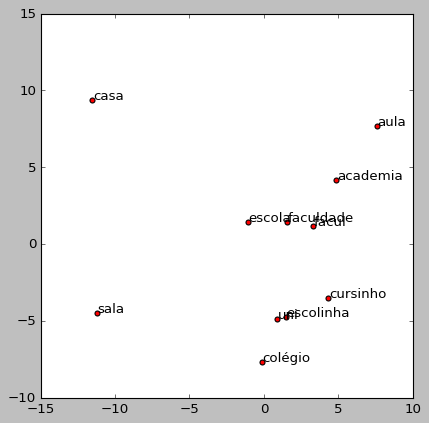

In [45]:
words = ['escola', 'faculdade', 'facul', 'aula', 'sala', 'colégio', 'academia', 'casa', 'escolinha', 'uni', 'cursinho']
display_pca_scatterplot(meu_modelo.wv,words)